## IMPORT LIBRARY
Kode ini adalah bagian awal dari program Python yang digunakan untuk pemrosesan data, gambar, dan visualisasi. Biasanya kode seperti ini dipakai dalam bidang image processing atau computer vision.
np (NumPy) → NumPy
Digunakan untuk mengolah angka, array, dan matriks, serta melakukan operasi matematika dengan cepat.
cv (OpenCV) → OpenCV
Digunakan untuk pemrosesan gambar dan video seperti membaca gambar, mengubah warna, blur, hingga deteksi objek.
plt (Matplotlib) → Matplotlib
Digunakan untuk menampilkan grafik atau gambar hasil olahan data agar bisa divisualisasikan dengan mudah.

In [309]:

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## Fungsi Menampilkan Citra
Kode berikut digunakan untuk membaca dan menampilkan gambar menggunakan Matplotlib. plt.imread('Assets/Meledak.png') dari Matplotlib berfungsi untuk membaca file gambar bernama Meledak.png yang berada di folder Assets, lalu hasilnya disimpan ke dalam variabel citra dalam bentuk array (kumpulan nilai pixel). Setelah itu, plt.imshow(citra) dari Matplotlib digunakan untuk menampilkan gambar tersebut di layar berdasarkan data yang sudah dibaca sebelumnya, sehingga gambar bisa terlihat secara visual pada output program.

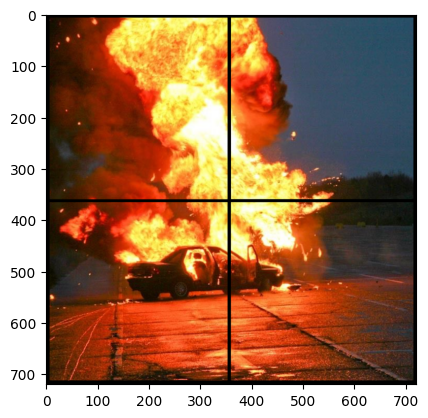

In [310]:
citra = plt.imread('Assets/Meledak.png')
plt.imshow(citra)

## Penjelasan Fungsi
Kode ini berisi beberapa fungsi untuk membaca, menstandarkan format, dan menampilkan citra (gambar) menggunakan OpenCV dan Matplotlib.

Pertama, pastikan_uint8(citra) berfungsi untuk memastikan data gambar berada dalam format uint8 (0–255). Jika gambar masih dalam bentuk float (0–1), maka nilainya dikalikan 255, lalu dibatasi dengan np.clip() dari NumPy agar tidak melebihi rentang 0–255, kemudian diubah ke tipe uint8.

Selanjutnya, baca_grayscale(path) dan baca_rgb(path) digunakan untuk membaca gambar menggunakan OpenCV. Fungsi grayscale membaca gambar dalam mode hitam-putih, sedangkan fungsi RGB membaca gambar berwarna lalu mengubah format dari BGR ke RGB agar sesuai dengan tampilan Python.

Terakhir, tampilkan_citra() digunakan untuk menampilkan gambar menggunakan Matplotlib. Jika gambar berbentuk 2D (grayscale), maka ditampilkan dengan mode abu-abu, sedangkan jika gambar berwarna langsung ditampilkan normal, kemudian judul ditambahkan dan axis dimatikan agar tampilan lebih rapi.

In [316]:
def pastikan_uint8(citra):
    citra = np.array(citra)

    if citra.dtype == np.uint8:
        return citra

    if citra.max() <= 1.0:
        citra = citra * 255
    return np.clip(citra, 0, 255).astype(np.uint8)

def baca_grayscale(path):
    citra = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if citra is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    return pastikan_uint8(citra)


def baca_rgb(path):
    citra_bgr = cv.imread(path, cv.IMREAD_COLOR)

    if citra_bgr is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    citra_rgb = cv.cvtColor(citra_bgr, cv.COLOR_BGR2RGB)
    return pastikan_uint8(citra_rgb)

def tampilkan_citra(citra, judul="Citra", cmap="gray", figsize=(8, 5)):
    plt.figure(figsize=figsize)

    if len(citra.shape) == 2:
        plt.imshow(citra, cmap=cmap)
    else:
        plt.imshow(citra)

    plt.title(judul)
    plt.axis("off")
    plt.show()

## Pemotongan Citra
Kode ini digunakan untuk memotong gambar menjadi beberapa bagian dan menampilkannya dalam 4 panel. Pertama dibuat fungsi slice(gambar, a, b, mode='H') untuk memotong gambar, jika mode 'H' maka dipotong secara horizontal (gambar[a:b, :]), sedangkan mode 'V' dipotong secara vertikal (gambar[:, a:b]). Kemudian gambar citra dibagi menjadi empat bagian berbeda (A, B, C, D) dengan kombinasi pemotongan horizontal dan vertikal untuk mengambil area tertentu dari gambar. Setelah itu, hasilnya ditampilkan menggunakan plt.subplot(2,2,...) dari Matplotlib agar gambar tampil dalam format 2x2, lalu plt.imshow() digunakan untuk menampilkan masing-masing bagian dengan judul “Citra A”, “Citra B”, “Citra C”, dan “Citra D”. Terakhir, plt.tight_layout() dipakai supaya tata letak gambar lebih rapi dan tidak saling bertumpuk.

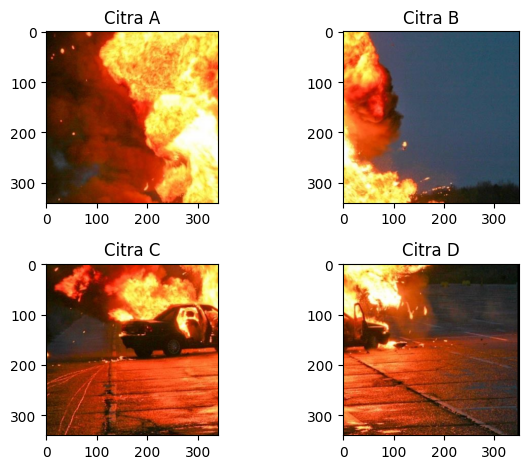

In [317]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

citra1 = slice(citra, 10, 350, mode='H')
HasilCitA = slice(citra1, 10, 350, mode='V')

citra2 = slice(citra, 10, 350, mode='H')
HasilCitB = slice(citra2, 360, 710, mode='V')

citra3 = slice(citra, 370, 710, mode='H')
HasilCitC = slice(citra3, 10, 350, mode='V')

citra4 = slice(citra, 370, 710, mode='H')
HasilCitD = slice(citra4, 370, 720, mode='V')

plt.subplot (2,2,1) 
plt.imshow(HasilCitA)
plt.title('Citra A')    

plt.subplot (2,2,2)
plt.imshow(HasilCitB)
plt.title('Citra B')

plt.subplot (2,2,3)
plt.imshow(HasilCitC)
plt.title('Citra C')

plt.subplot (2,2,4)
plt.imshow(HasilCitD)
plt.title('Citra D')

plt.tight_layout()

## Penggabungan Citra

Kode ini digunakan untuk menggabungkan beberapa citra (gambar) menjadi satu gambar besar, baik secara horizontal maupun vertikal, lalu menampilkannya.

Fungsi merge(citra1, citra2, orientation='H') bekerja dengan cara menggabungkan dua gambar. Jika orientation = 'H', maka gambar digabung secara horizontal (sebelah kanan-kiri) dengan membuat kanvas kosong menggunakan np.zeros() dari NumPy, lalu kedua citra dimasukkan ke posisi masing-masing. Jika orientation = 'V', maka gambar digabung secara vertikal (atas-bawah) dengan cara yang sama tetapi posisi penempatannya berbeda.

Setelah fungsi dibuat, GabungAtas menggabungkan HasilCitA dan HasilCitB secara horizontal, GabungBawah menggabungkan HasilCitC dan HasilCitD secara horizontal, lalu GabungAtasBawah menggabungkan keduanya secara vertikal sehingga membentuk satu gambar utuh. Terakhir, hasil gabungan tersebut ditampilkan menggunakan plt.imshow() dari Matplotlib.

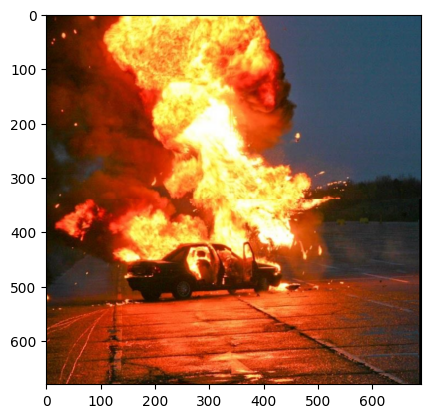

In [318]:
def merge(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

GabungAtas = merge(HasilCitA, HasilCitB, "H")
GabungBawah = merge(HasilCitC, HasilCitD, "H")
GabungAtasBawah = merge(GabungAtas, GabungBawah, "V")

plt.imshow(GabungAtasBawah)

# Ubah Menjadi Grayscale
Kode ini digunakan untuk mengubah gambar berwarna menjadi grayscale (hitam putih) lalu menampilkannya.

cv.cvtColor(GabungAtasBawah, cv.COLOR_BGR2GRAY) dari OpenCV berfungsi untuk mengonversi gambar GabungAtasBawah yang masih berformat warna (BGR) menjadi citra grayscale, yaitu gambar yang hanya memiliki intensitas cahaya tanpa warna. Hasil konversi ini disimpan ke variabel citraGray. Setelah itu, tampilkan_citra(citraGray) digunakan untuk menampilkan hasil gambar tersebut menggunakan fungsi tampilan yang sudah dibuat sebelumnya, sehingga output yang muncul adalah gambar hitam putih dari hasil gabungan citra.

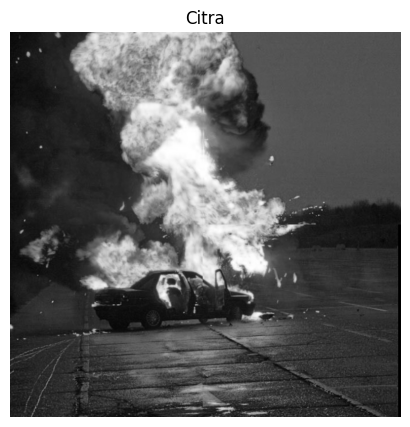

In [314]:
citraGray = cv.cvtColor(GabungAtasBawah,cv.COLOR_BGR2GRAY)
tampilkan_citra(citraGray)

## Ekualisasi
Kode ini digunakan untuk mengolah citra grayscale dengan teknik histogram equalization (ekualisasi histogram) agar gambar menjadi lebih jelas dan kontrasnya meningkat.

Pertama, fungsi buat_hist(citra) digunakan untuk menghitung histogram citra, yaitu jumlah kemunculan setiap intensitas pixel (0–255). Setelah itu, hitung_cdf(citra) menghitung CDF (Cumulative Distribution Function) dengan menjumlahkan histogram secara bertahap untuk mengetahui distribusi kumulatif intensitas pixel.

Selanjutnya, fungsi ekualisasi_histogram(citra) melakukan proses utama yaitu meningkatkan kontras gambar. Di dalamnya, nilai CDF dinormalisasi ke rentang 0–255 menggunakan NumPy dari NumPy, lalu setiap pixel pada citra diganti dengan nilai baru berdasarkan CDF tersebut sehingga gambar menjadi lebih merata intensitasnya.

Hasil ekualisasi kemudian disimpan di HasilEkualisasi, lalu ditampilkan menggunakan plt.subplot() dari Matplotlib untuk membandingkan gambar sebelum dan sesudah ekualisasi, di mana sisi kiri menampilkan citra awal dan sisi kanan menampilkan citra hasil perbaikan kontras.

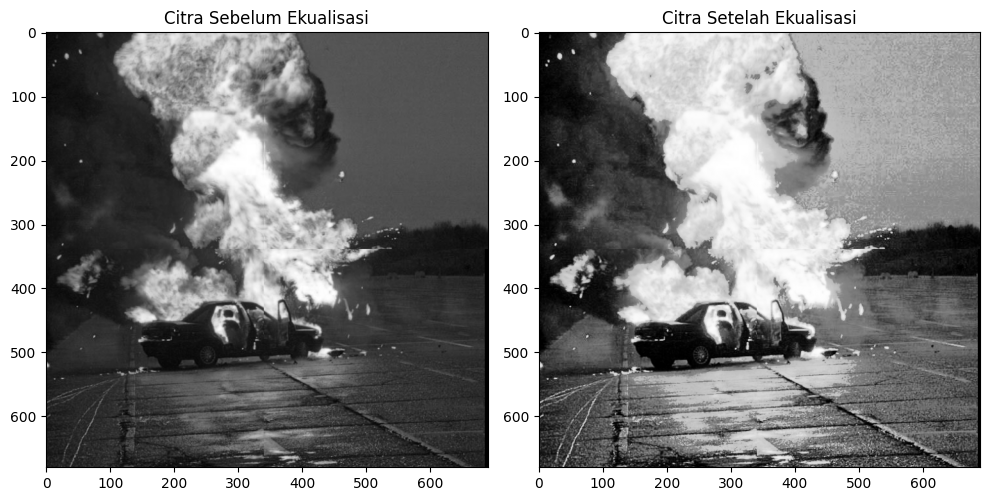

In [319]:
def buat_hist(citra):
    citra = pastikan_uint8(citra)

    hist = np.zeros(256, dtype=int)

    tinggi, lebar = citra.shape

    for i in range(tinggi):
        for j in range(lebar):
            intensitas = int(citra[i, j])
            hist[intensitas] += 1

    return hist

def hitung_cdf(citra):
    hist = buat_hist(citra)
    cdf = np.zeros(256, dtype=float)

    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    return hist, cdf

def ekualisasi_histogram(citra):
    citra = pastikan_uint8(citra)

    tinggi, lebar = citra.shape

    hist, cdf = hitung_cdf(citra)

    cdf_normal = (cdf - cdf.min()) / (cdf.max() - cdf.min()) * 255
    cdf_normal = np.round(cdf_normal).astype(np.uint8)

    hasil = np.zeros_like(citra)

    for i in range(tinggi):
        for j in range(lebar):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

HasilEkualisasi = ekualisasi_histogram(citraGray)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(citraGray, cmap='gray')
plt.title("Citra Sebelum Ekualisasi")

plt.subplot(1,2,2)
plt.imshow(HasilEkualisasi, cmap='gray')
plt.title("Citra Setelah Ekualisasi")

plt.tight_layout()
plt.show()

## Ekualisasi Histogram

Kode ini digunakan untuk menampilkan histogram citra sebelum dan sesudah ekualisasi agar bisa dibandingkan perubahan distribusi intensitas pixelnya.

Pertama, fungsi plot_histogram(histogram, title, ImgColor) dibuat untuk menampilkan histogram dalam bentuk diagram batang, di mana sumbu X menunjukkan intensitas piksel (0–255) dan sumbu Y menunjukkan jumlah piksel, lalu data histogram ditampilkan menggunakan plt.bar() dari Matplotlib.

Kemudian dibuat dua histogram yaitu hist_sebelum dari citra grayscale awal dan hist_sesudah dari citra hasil ekualisasi. Setelah itu, kedua histogram tersebut ditampilkan dalam satu grafik menggunakan Matplotlib, dengan warna berbeda (hijau untuk sebelum ekualisasi dan merah untuk sesudah ekualisasi) agar perbedaannya mudah terlihat. Fungsi alpha=0.6 digunakan agar kedua grafik bisa terlihat meskipun saling bertumpuk, dan plt.legend() menambahkan keterangan supaya grafik lebih mudah dipahami.

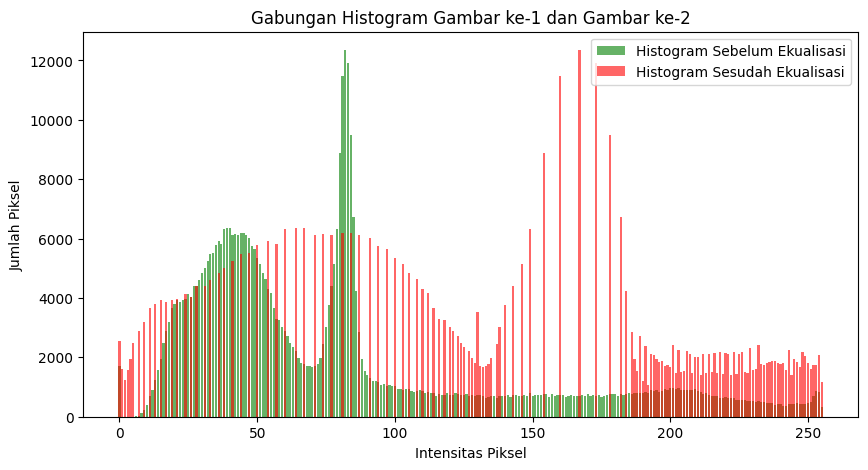

In [320]:

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

hist_sebelum = buat_hist(citraGray)
hist_sesudah = buat_hist(HasilEkualisasi)

plt.figure(figsize=(10, 5))
plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")

plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, width=0.8, label='Histogram Sebelum Ekualisasi')

plt.bar(range(256), hist_sesudah, color='red', alpha=0.6, width=0.8, label='Histogram Sesudah Ekualisasi')

plt.legend()
plt.show()

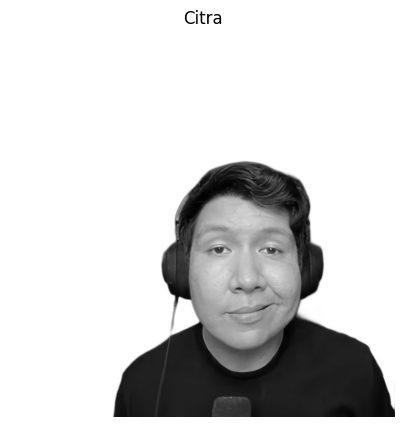

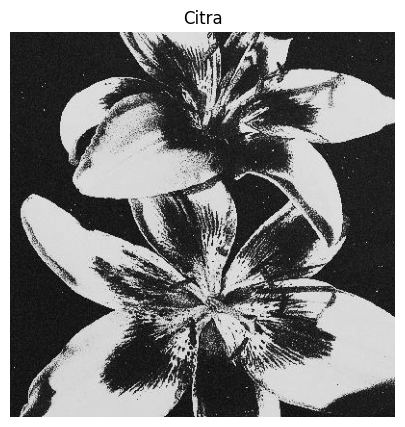

In [ ]:
windut = baca_grayscale('Assets/Windut.png')
bunga = baca_grayscale('Assets/Bunga.png')

tampilkan_citra(windut)
tampilkan_citra(bunga)

## Spesifikasi Histogram
Kode ini digunakan untuk melakukan histogram specification (penyesuaian histogram), yaitu mengubah distribusi intensitas citra agar menyerupai citra lain.

Fungsi spesifikasi_histogram(citra_asal, citra_target) diawali dengan memastikan kedua citra dalam format uint8 (0–255) menggunakan NumPy dari NumPy. Lalu dicek apakah keduanya berupa citra grayscale (2D), jika tidak maka akan muncul error. Setelah itu dihitung histogram dan CDF (Cumulative Distribution Function) dari kedua citra menggunakan fungsi sebelumnya.

CDF kemudian dinormalisasi agar berada di rentang 0–1, lalu dibuat pemetaan intensitas (map_hist) dengan cara mencocokkan setiap nilai intensitas citra asal dengan nilai CDF yang paling mendekati pada citra target. Setelah itu, setiap pixel citra asal diganti sesuai mapping tersebut untuk menghasilkan citra baru (hasil).

Hasil proses ini kemudian disimpan pada hasilSpesifikasi dan ditampilkan bersama citra asli (windut) dan citra target (bunga) menggunakan plt.subplot() dari Matplotlib, sehingga bisa dibandingkan langsung perubahan distribusi warnanya sebelum dan sesudah spesifikasi histogram.

In [ ]:
def spesifikasi_histogram(citra_asal, citra_target):
    citra_asal = pastikan_uint8(citra_asal)
    citra_target = pastikan_uint8(citra_target)

    if len(citra_asal.shape) != 2 or len(citra_target.shape) != 2:
        raise ValueError("spesifikasi_histogram hanya menerima citra grayscale 2D.")

    tinggi, lebar = citra_asal.shape

    hist_asal, cdf_asal = hitung_cdf(citra_asal)
    hist_target, cdf_target = hitung_cdf(citra_target)

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        selisih_terkecil = abs(cdf_asal[i] - cdf_target[0])
        indeks_terdekat = 0

        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                indeks_terdekat = j

        map_hist[i] = indeks_terdekat

    hasil = np.zeros_like(citra_asal, dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            nilai_lama = citra_asal[i, j]
            hasil[i, j] = map_hist[nilai_lama]

    return hasil


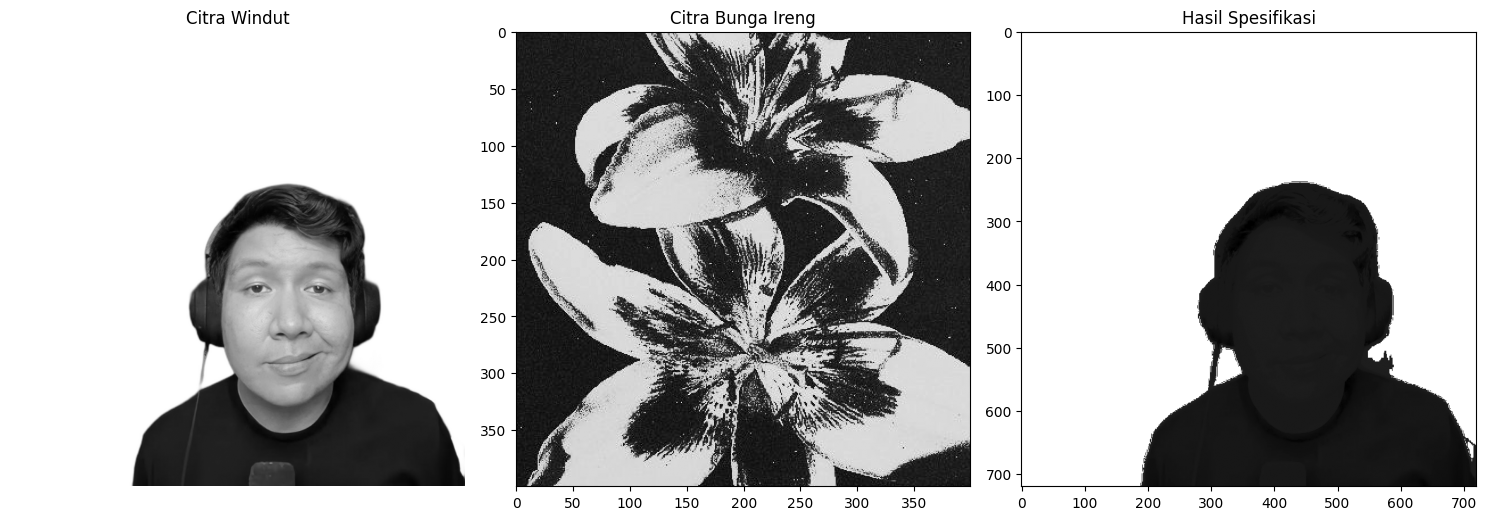

In [ ]:
hasilSpesifikasi = spesifikasi_histogram(windut, bunga)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(windut, cmap="gray")
plt.title("Citra Windut")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bunga, cmap="gray")
plt.title("Citra Bunga Ireng")

plt.subplot(1,3,3)
plt.imshow(hasilSpesifikasi, cmap="gray")
plt.title("Hasil Spesifikasi")

plt.tight_layout()
plt.show()

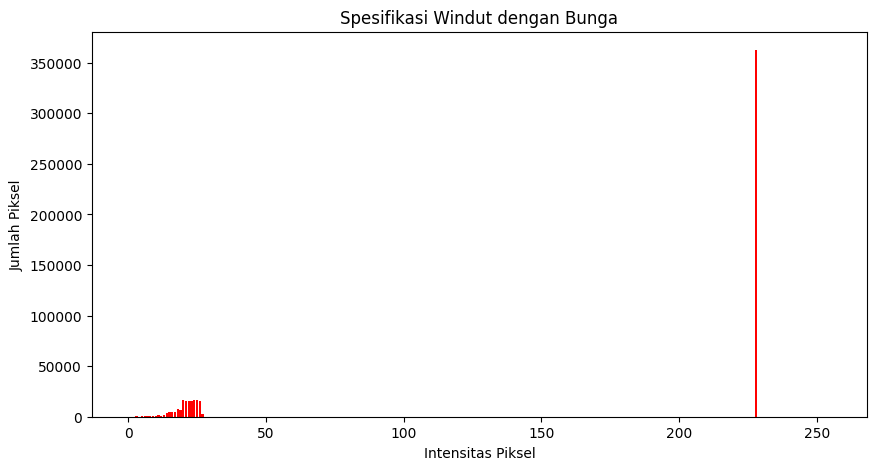

In [321]:
hist_hasil = buat_hist(hasilSpesifikasi)

plot_histogram(hist_hasil, "Spesifikasi Windut dengan Bunga", "red")

## Cropping dan Masking
Kode ini digunakan untuk melakukan cropping dua gambar agar ukurannya sama, membuat mask (filter), lalu menerapkannya untuk menghasilkan gambar akhir dengan bagian tertentu dihilangkan.

Pertama, fungsi crop_sama_ukuran(citra1, citra2) digunakan untuk menyamakan ukuran dua gambar dengan mengambil ukuran terkecil dari keduanya, lalu memotong (crop) kedua citra agar memiliki tinggi dan lebar yang sama. Setelah itu, buat_mask_threshold(citra, threshold=250) membuat masking biner berdasarkan nilai intensitas pixel, di mana pixel yang nilainya kurang dari 250 akan bernilai True (dipertahankan), dan sisanya akan dianggap background. Fungsi terapkan_mask(background, mask) kemudian menerapkan mask tersebut ke gambar background menggunakan NumPy dari NumPy, dengan cara mengubah pixel yang terkena mask menjadi 0 (hitam).

Selanjutnya, citra windut dan HasilEkualisasi dipastikan dalam format uint8, kemudian dicrop agar ukurannya sama. Setelah itu dibuat mask dari citra windut_crop, lalu mask tersebut diterapkan ke background_crop sehingga menghasilkan gambar akhir hasil_masking. Terakhir, hasilnya ditampilkan menggunakan plt.imshow()

In [ ]:
def crop_sama_ukuran(citra1, citra2):
    tinggi = min(citra1.shape[0], citra2.shape[0])
    lebar = min(citra1.shape[1], citra2.shape[1])

    citra1_crop = citra1[:tinggi, :lebar]
    citra2_crop = citra2[:tinggi, :lebar]

    return citra1_crop, citra2_crop

def buat_mask_threshold(citra, threshold=250):
    citra = pastikan_uint8(citra)
    return citra < threshold


def terapkan_mask(background, mask):
    hasil = np.copy(background)
    hasil[mask] = 0
    return hasil

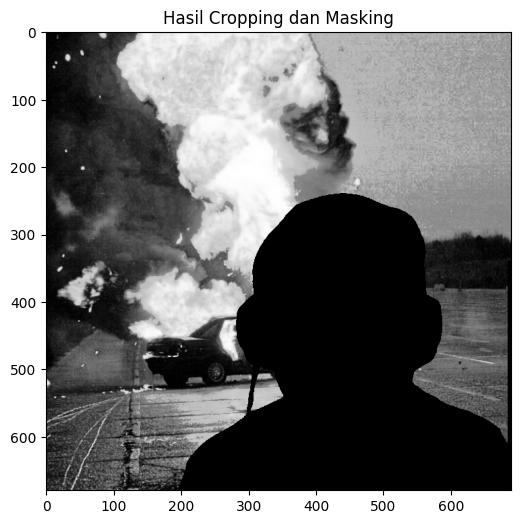

In [ ]:
windut = pastikan_uint8(windut)
HasilEkualisasi = pastikan_uint8(HasilEkualisasi) 

windut_crop, background_crop = crop_sama_ukuran(
    windut,
    HasilEkualisasi
)

mask = buat_mask_threshold(
    windut_crop,
    threshold=250
)

hasil_masking = terapkan_mask(
    background_crop,
    mask
)
plt.figure(figsize=(6,6))
plt.imshow(hasil_masking, cmap='gray')
plt.title("Hasil Cropping dan Masking")
plt.show()

## Penggabungan Citra

Kode ini digunakan untuk menggabungkan dua citra (objek dan background) berdasarkan nilai intensitas pixel menggunakan threshold, sehingga objek tertentu bisa “ditumpangkan” di atas background.

Fungsi gabung_citra(objek, background, threshold=240) bekerja dengan cara membuat salinan dari background menggunakan NumPy dari NumPy, lalu membandingkan setiap pixel pada citra objek. Jika nilai pixel objek lebih kecil dari threshold (kurang dari 240), maka pixel tersebut akan diambil dan menggantikan pixel pada background, sehingga area objek tetap terlihat sementara bagian lain tetap background.

Sebelum proses penggabungan, kedua citra (windut dan HasilEkualisasi) disamakan ukurannya menggunakan fungsi crop_sama_ukuran, lalu dipastikan dalam format uint8. Hasil penggabungan disimpan dalam hasil_gabung, kemudian ditampilkan menggunakan plt.imshow() dari Matplotlib dalam mode grayscale, sehingga terlihat hasil akhir citra yang sudah digabung berdasarkan threshold.

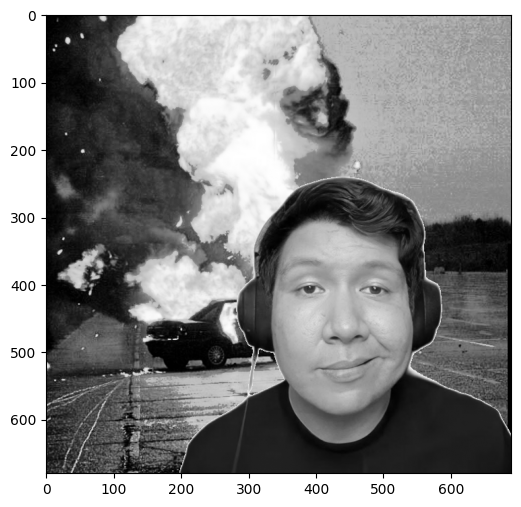

In [ ]:
def gabung_citra(objek, background, threshold=240):
    tinggi, lebar = objek.shape
    hasil = np.copy(background)

    for i in range(tinggi):
        for j in range(lebar):

            if objek[i, j] < threshold:
                hasil[i, j] = objek[i, j]

    return hasil
windut = pastikan_uint8(windut)
HasilEkualisasi = pastikan_uint8(HasilEkualisasi)


windut_crop, background_crop = crop_sama_ukuran(
    windut,
    HasilEkualisasi
)

hasil_gabung = gabung_citra(
    windut_crop,
    background_crop,
    threshold=240
)

plt.figure(figsize=(6,6))
plt.imshow(hasil_gabung, cmap='gray')
plt.show() 

Pertama, gambar Langit.png dibaca menggunakan cv.imread() dari OpenCV, lalu diubah menjadi grayscale dengan cv.cvtColor() agar hanya memiliki intensitas cahaya tanpa warna. Setelah itu dilakukan pengecekan tipe data, jika belum uint8 maka dinormalisasi ke rentang 0–255 agar sesuai format citra digital.

Selanjutnya, fungsi spesifikasi_histogram(hasil_gabung, langit_gray) digunakan untuk mencocokkan distribusi intensitas citra hasil_gabung agar menyerupai citra langit_gray, sehingga karakteristik kecerahan dan kontrasnya mengikuti gambar langit.

Terakhir, hasil transformasi disimpan dalam hasil_sempurna dan ditampilkan menggunakan plt.imshow() dari Matplotlib dengan judul “Windut Ganteng”, sehingga terlihat hasil akhir citra yang sudah disesuaikan histogramnya.

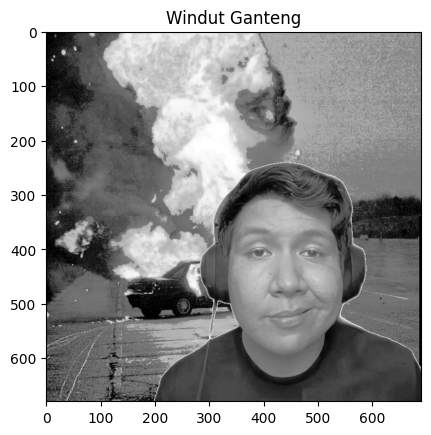

In [ ]:
langit = cv.imread('assets/Langit.png')
langit_gray = cv.cvtColor(langit, cv.COLOR_BGR2GRAY)

if langit_gray.dtype != np.uint8:
    langit_gray = (langit_gray * 255).astype(np.uint8)

hasil_sempurna = spesifikasi_histogram(hasil_gabung, langit_gray)

plt.imshow(hasil_sempurna, cmap='gray')
plt.title("Windut Ganteng")
plt.show()

Kode ini digunakan untuk menghitung histogram dari hasil citra akhir (hasil spesifikasi dengan langit) lalu menampilkannya dalam bentuk grafik batang agar distribusi intensitas pixel bisa dianalisis.

Pertama, hist_hasil = buat_hist(hasil_sempurna) menghitung histogram dari citra hasil_sempurna, yaitu dengan menghitung jumlah kemunculan setiap nilai intensitas piksel (0–255) menggunakan perhitungan array dari NumPy NumPy.

Setelah itu, plot_histogram(hist_hasil, "Spesifikasi Windut dengan Langit", "red") digunakan untuk menampilkan histogram tersebut dalam bentuk diagram batang menggunakan Matplotlib Matplotlib, dengan judul “Spesifikasi Windut dengan Langit” dan warna merah agar mudah dibedakan serta terlihat jelas perubahan distribusi intensitas pixel pada citra akhir.

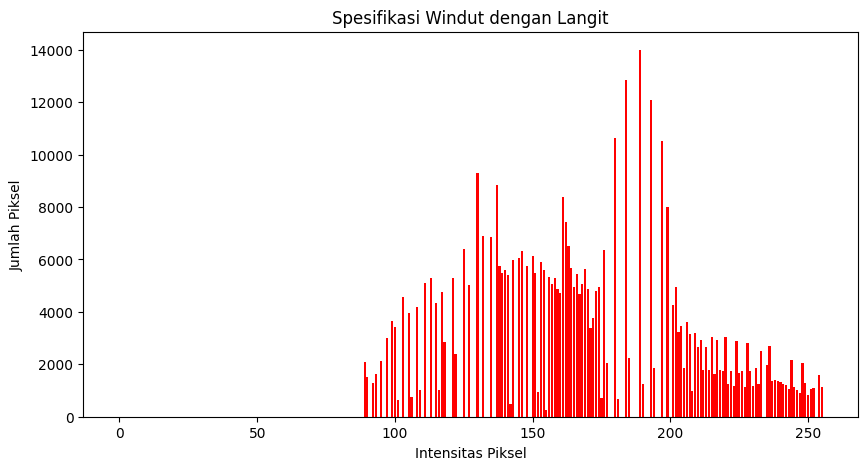

In [ ]:
hist_hasil = buat_hist(hasil_sempurna)

plot_histogram(hist_hasil, "Spesifikasi Windut dengan Langit", "red")

Kode ini digunakan untuk menggabungkan dua gambar berwarna (Windut dan background) dengan teknik masking warna putih, sehingga bagian putih pada objek diganti dengan background.

Pertama, gambar Windut.png dibaca sebagai citra berwarna menggunakan OpenCV. Lalu background diambil dari GabungAtasBawah, kemudian disesuaikan format warnanya agar menjadi RGB, dan jika bentuknya grayscale diubah menjadi 3 channel (RGB). Setelah itu dilakukan normalisasi agar semua nilai pixel berada pada rentang uint8 (0–255).

Selanjutnya, kedua gambar (background dan windut) dipotong agar memiliki ukuran yang sama (tinggi dan lebar minimum). Setelah itu dibuat citra kosong hasil untuk menampung hasil akhir.

Proses utama dilakukan dengan looping setiap pixel, di mana jika pixel pada Windut bukan warna putih (nilai RGB tidak mendekati 245 ke atas) maka pixel tersebut dipertahankan, tetapi jika pixel putih maka diganti dengan pixel dari background. Ini berfungsi seperti “menghapus background putih”.

Terakhir, hasil gabungan ditampilkan menggunakan plt.imshow()

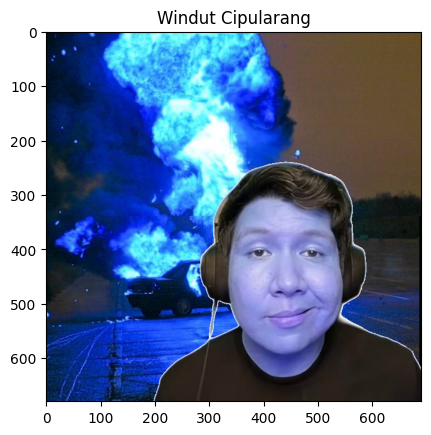

In [ ]:
windut_color = cv.imread('assets/Windut.png')

background_color = GabungAtasBawah.copy()
if len(background_color.shape) == 3:
    background_color = background_color[:, :, :3][:, :, ::-1] 

if len(background_color.shape) == 2:
    background_color = np.stack((background_color,) * 3, axis=-1)

if background_color.max() <= 1.0:
    background_color = (background_color * 255).astype(np.uint8)

background_color = background_color.astype(np.uint8)

h_bg, w_bg, _ = background_color.shape
h_w, w_w, _ = windut_color.shape

h_min = min(h_bg, h_w)
w_min = min(w_bg, w_w)

background_crop = background_color[0:h_min, 0:w_min]
windut_crop = windut_color[0:h_min, 0:w_min]

hasil = np.zeros((h_min, w_min, 3), dtype=np.uint8)

batas_putih = 245

for y in range(h_min):
    for x in range(w_min):
        b = windut_crop[y, x, 0]
        g = windut_crop[y, x, 1]
        r = windut_crop[y, x, 2]
        
        if not (b > batas_putih and g > batas_putih and r > batas_putih):
            hasil[y, x] = windut_crop[y, x]
        else:
            hasil[y, x] = background_crop[y, x]

plt.imshow(hasil)
plt.title("Windut Cipularang")
plt.show()